# Notebook base: Mecanica Celeste

Este notebook queda listo para trabajar con `numpy`, `matplotlib`, `pymcel` y `rebound`.

1. Ejecuta la celda de instalacion (solo una vez por entorno).
2. Reinicia el kernel si Jupyter lo sugiere.
3. Ejecuta las celdas de prueba.

In [1]:
# Instalacion de paquetes (si ya estan instalados, puedes omitir esta celda)
%pip install -q numpy matplotlib pymcel rebound

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import rebound

# pymcel puede variar segun version/distribucion
try:
    import pymcel
    pymcel_ok = True
except Exception as e:
    pymcel_ok = False
    pymcel_error = e

print(f'numpy: {np.__version__}')
print(f'matplotlib: {plt.matplotlib.__version__}')
print(f'rebound: {rebound.__version__}')
if pymcel_ok:
    print('pymcel: importado correctamente')
else:
    print(f'pymcel: no se pudo importar -> {pymcel_error}')

Bienvenido a PyMCel v0.9.17 ¡al infinito y más allá!
numpy: 2.4.3
matplotlib: 3.10.8
rebound: 4.6.0
pymcel: importado correctamente


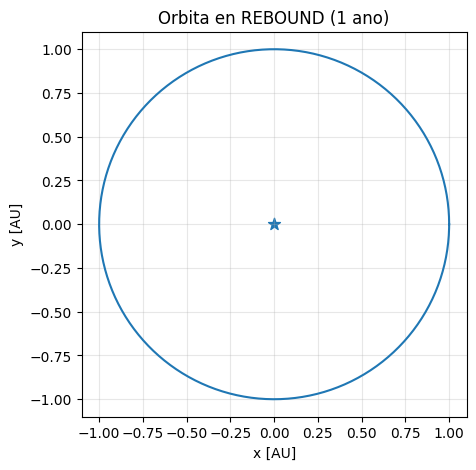

In [ ]:
# Mini ejemplo con REBOUND: orbita circular aproximada
sim = rebound.Simulation()
sim.G = 4 * np.pi**2
sim.add(m=1.0)          # estrella
sim.add(m=3e-6, a=1.0)  # planeta tipo Tierra
sim.move_to_com()

N = 300
times = np.linspace(0, 1.0, N)
xs, ys = np.zeros(N), np.zeros(N)

for i, t in enumerate(times):
    sim.integrate(t)
    p = sim.particles[1]
    xs[i], ys[i] = p.x, p.y

plt.figure(figsize=(5, 5))
plt.plot(xs, ys)
plt.scatter([0], [0], s=80, marker='*')
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Orbita (1 año)')
plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.grid(True, alpha=0.3)
plt.show()